# Gene Expression Correlation Analysis

This notebook analyzes correlation patterns between genes by comparing their mean expression levels across cells.

**Workflow:**
1. Calculate mean expression per gene per cell
2. Z-score normalize gene expressions
3. Compute correlation matrix between genes
4. Cluster genes using hierarchical clustering
5. Visualize as heatmap and network graph

---

## Setup

In [3]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tifffile import imread
from skimage.filters import threshold_otsu
from tqdm import tqdm
from scipy.cluster.hierarchy import dendrogram, linkage, leaves_list
from scipy.spatial.distance import squareform
import networkx as nx

## Configuration

In [5]:
# Analysis parameters
TARGET_GENE = 'RELA'
CELL_LINE = 'A-431'
N_CELLS = 15

# Gene list to analyze
gene_names = ['MAP3K8', 'BCL3', 'BRD4', 'NUTM1', 'RELB', 'HDAC1', 'NFKBIB', 'NFKB2',
              'REL', 'EP300', 'CITED4', 'NFKBIE', 'NFKBIA', 'NFKB1', 'CREBBP', 'EGR3', 
              'NFKBIZ', 'NFKBID', 'KLF2', 'GREB1', TARGET_GENE]


# Correlation thresholds for network visualization
POS_THRESHOLD = 0.5  # Positive correlation threshold
NEG_THRESHOLD = 0.5  # Negative correlation threshold

# Directories
REAL_IMAGE_DIR = f"RELA_A-431"
PRED_IMAGE_DIR = f"RELA_{CELL_LINE}_output"
RESULT_DIR = f"{TARGET_GENE}_results"

os.makedirs(RESULT_DIR, exist_ok=True)

print(f"Analyzing {len(gene_names)} genes in {CELL_LINE}")
print(f"Results: {RESULT_DIR}/")

Analyzing 21 genes in A-431
Results: RELA_results/


## Helper Functions

In [11]:
def calculate_mean_expression(image, thresh_multiplier=1.25):
    """Calculate mean expression in thresholded regions."""
    thresh = thresh_multiplier * threshold_otsu(image)
    binary_mask = image > thresh
    
    if np.any(binary_mask):
        return np.mean(image[binary_mask])
    return 0.0

def zscore_normalize(df, gene_cols):
    """Z-score normalize each gene across cells."""
    df_norm = df.copy()
    
    for col in gene_cols:
        vals = df[col].values
        finite_vals = vals[np.isfinite(vals)]
        
        if len(finite_vals) > 0:
            mean_val = np.mean(finite_vals)
            std_val = np.std(finite_vals)
            df_norm[col] = (df[col] - mean_val) / (std_val + 1e-8)
    
    return df_norm

def reorder_by_clustering(corr_matrix, gene_names):
    """Reorder correlation matrix using hierarchical clustering."""
    # Convert correlation to distance
    distance_matrix = 1 - corr_matrix
    condensed_dist = squareform(distance_matrix, checks=False)
    
    # Hierarchical clustering
    linkage_matrix = linkage(condensed_dist, method='average')
    order = leaves_list(linkage_matrix)
    
    # Reorder
    reordered_matrix = corr_matrix[order, :][:, order]
    reordered_genes = [gene_names[i] for i in order]
    
    return reordered_matrix, reordered_genes, linkage_matrix

## Prepare CSV for ProtVL Image Generation

Generate a CSV file specifying which genes to generate for correlation analysis.

In [6]:
# Create generation list
generation_data = []

input_image_dir = 'RELA_A-431'

image_paths = []
gene_list = []
cell_line_list = []

for filename in os.listdir(input_image_dir):
    parts = filename.strip('.tiff').split('_')
    cell_line = CELL_LINE
    
    # Generate all genes for this cell
    for gene in gene_names:
        if gene == TARGET_GENE:
            continue  # Skip target gene (use real images)
        
        generation_data.append({
            'image_path': filename,
            'gene_name': gene,
            'cell_line_name': CELL_LINE
        })

# Create CSV for ProtVL
generation_df = pd.DataFrame(generation_data)
generation_df.to_csv(f'{TARGET_GENE}_{CELL_LINE}_generation.csv', index=False)

print(f"Created CSV with {len(generation_df)} images to generate")
print(f"  {N_CELLS} cells x {len(gene_names)-1} genes")
print(f"  Output: {TARGET_GENE}_{CELL_LINE}_generation.csv")

Created CSV with 300 images to generate
  15 cells x 20 genes
  Output: RELA_A-431_generation.csv


## Generate Images with ProtVL

Before proceeding with analysis, run ProtVL to generate predicted protein expression images. This step is performed outside the notebook.

**Command:**
```bash
python ordinary_sampler_standalone.py \
    --csv_file_path {TARGET_GENE}_{CELL_LINE}_generation.csv \
    --model_path ./checkpoint-1020000/ \
    --vae_path ./vae \
    --cell_line_map_path cell_line_map.pkl \
    --antibody_map_path antibody_map.pkl \
    --mixed_precision no \
    --output_dir ./{TARGET_GENE}_{CELL_LINE}_output \
    --batch_size 16 \
    --num_workers 0 \
    --num_inference_steps 100
```

**Outputs:**
- Generated images will be saved to `./{TARGET_GENE}_{CELL_LINE}_output/`
- Real target gene images should be in `./{TARGET_GENE}_{CELL_LINE}/`
- Filenames follow pattern: `cell_{i}_{CELL_LINE}_{gene}_pred.tif`

**Note:** Ensure `PRED_IMAGE_DIR` and `REAL_IMAGE_DIR` point to the correct directories before running the analysis cells.

## Calculate Mean Expression Per Cell

Load predicted images and calculate mean expression for each gene in each cell.

In [22]:
cell_data = []

for i in tqdm(range(N_CELLS), desc=f"Processing {CELL_LINE}"):
    cell_expr = {'cell_id': f"{CELL_LINE}_cell_{i}"}
    
    # Load target gene (real image) for mask
    real_path = f"{REAL_IMAGE_DIR}/cell_{i}.tiff"
    if not os.path.exists(real_path):
        continue
    
    real_image = imread(real_path)[:, :, 1].astype(np.float32)
    real_image = (real_image + 1) / 2  # Normalize
    cell_expr[TARGET_GENE] = calculate_mean_expression(real_image)
    
    # Load predicted images for other genes
    for gene in gene_names:
        if gene == TARGET_GENE:
            continue
            
        pred_path = f"{PRED_IMAGE_DIR}/cell_{i}_{CELL_LINE}_{gene}_pred.tif"
        if not os.path.exists(pred_path):
            continue
        
        pred_image = imread(pred_path)
        if pred_image.ndim == 3:
            pred_image = pred_image[:, :, 1].astype(np.float32)
        
        cell_expr[gene] = calculate_mean_expression(pred_image)
    
    cell_data.append(cell_expr)

# Create expression dataframe
expression_df = pd.DataFrame(cell_data)
expression_df.set_index('cell_id', inplace=True)

print(f"\nProcessed {len(expression_df)} cells")
print(f"Genes with data: {len(expression_df.columns)}")

# Save raw expression
expression_df.to_csv(f"{RESULT_DIR}/{CELL_LINE}_expression.csv")
pickle.dump(expression_df, open(f"{RESULT_DIR}/{CELL_LINE}_expression.pkl", "wb"))

Processing A-431: 100%|██████████| 15/15 [00:01<00:00,  9.55it/s]


Processed 15 cells
Genes with data: 19


## Z-score Normalization and Correlation

In [23]:
# Z-score normalize
available_genes = [g for g in gene_names if g in expression_df.columns]
expression_zscore = zscore_normalize(expression_df, available_genes)

# Save normalized data
expression_zscore.to_csv(f"{RESULT_DIR}/{CELL_LINE}_expression_zscore.csv")
pickle.dump(expression_zscore, open(f"{RESULT_DIR}/{CELL_LINE}_expression_zscore.pkl", "wb"))

# Calculate correlation matrix
data = expression_zscore[available_genes].values
mask = np.all(np.isfinite(data), axis=1)
data_clean = data[mask]

corr_matrix = np.corrcoef(data_clean.T)

# Save correlation matrix
corr_df = pd.DataFrame(corr_matrix, index=available_genes, columns=available_genes)
corr_df.to_csv(f"{RESULT_DIR}/{CELL_LINE}_correlation_matrix.csv")

print(f"Correlation matrix: {corr_matrix.shape}")

Correlation matrix: (19, 19)


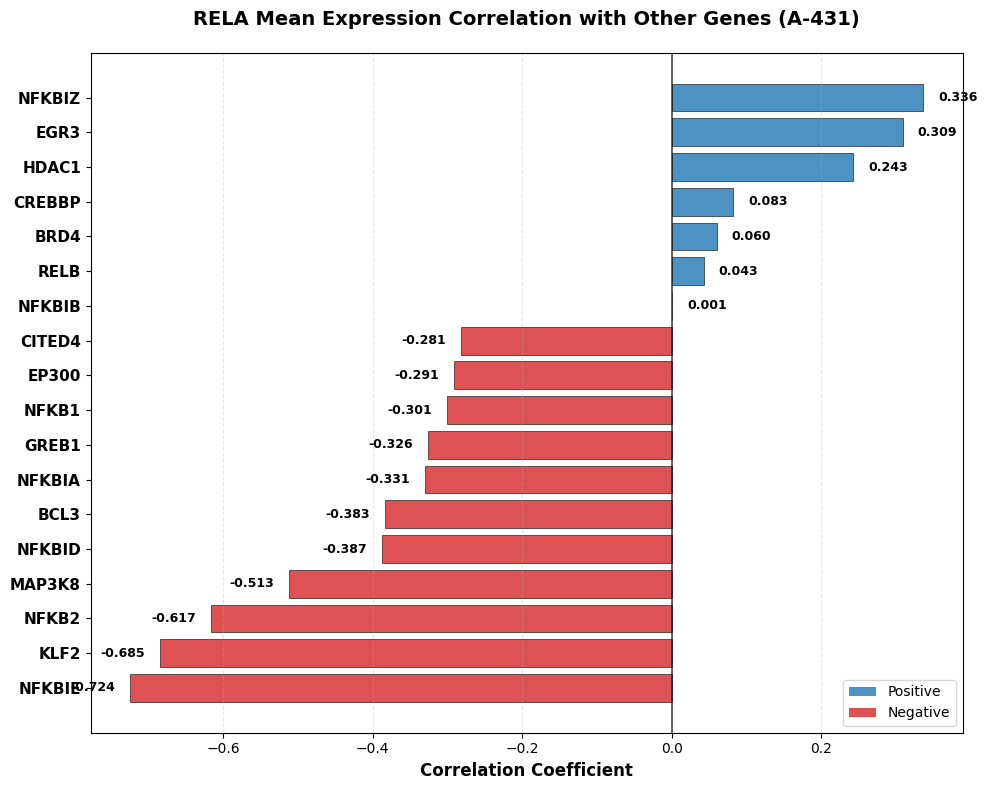


RELA correlations:
  Mean: -0.209
  Top 3 positive: NFKBIZ (0.336), EGR3 (0.309), HDAC1 (0.243)
  Top 3 negative: NFKBIE (-0.724), KLF2 (-0.685), NFKB2 (-0.617)


In [24]:
# Extract target gene correlations from matrix
if TARGET_GENE in available_genes:
    target_idx = available_genes.index(TARGET_GENE)
    target_correlations = corr_matrix[target_idx, :]
    
    # Get other genes (exclude self-correlation)
    other_genes = [g for i, g in enumerate(available_genes) if i != target_idx]
    other_corrs = [corr_matrix[target_idx, i] for i in range(len(available_genes)) if i != target_idx]
    
    # Sort genes by correlation
    sorted_idx = np.argsort(other_corrs)
    genes_sorted = [other_genes[i] for i in sorted_idx]
    corr_sorted = [other_corrs[i] for i in sorted_idx]
    
    # Create color map (negative = red, positive = blue)
    colors = ['#d62728' if c < 0 else '#1f77b4' for c in corr_sorted]
    
    # Create horizontal bar plot
    fig, ax = plt.subplots(figsize=(10, 8))
    y_pos = np.arange(len(genes_sorted))
    bars = ax.barh(y_pos, corr_sorted, color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
    
    # Customize plot
    ax.set_yticks(y_pos)
    ax.set_yticklabels(genes_sorted, fontsize=11, fontweight='bold')
    ax.set_xlabel('Correlation Coefficient', fontsize=12, fontweight='bold')
    ax.set_title(f'{TARGET_GENE} Mean Expression Correlation with Other Genes ({CELL_LINE})', 
                 fontsize=14, fontweight='bold', pad=20)
    ax.axvline(x=0, color='black', linestyle='-', linewidth=1.2, alpha=0.7)
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    
    # Add value labels
    for bar, val in zip(bars, corr_sorted):
        x_pos = val + (0.02 if val > 0 else -0.02)
        ha = 'left' if val > 0 else 'right'
        ax.text(x_pos, bar.get_y() + bar.get_height()/2, f'{val:.3f}',
                va='center', ha=ha, fontsize=9, fontweight='bold')
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#1f77b4', alpha=0.8, label='Positive'),
        Patch(facecolor='#d62728', alpha=0.8, label='Negative')
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=10)
    
    plt.tight_layout()
    plt.savefig(f'{RESULT_DIR}/{CELL_LINE}_{TARGET_GENE}_gene_correlations.png', 
                dpi=300, bbox_inches='tight')
    plt.show()
    
    # Save results
    target_corr_df = pd.DataFrame({
        'Gene': genes_sorted,
        'Correlation_with_' + TARGET_GENE: corr_sorted
    })
    target_corr_df.to_csv(f'{RESULT_DIR}/{CELL_LINE}_{TARGET_GENE}_gene_correlations.csv', 
                          index=False)
    
    print(f"\n{TARGET_GENE} correlations:")
    print(f"  Mean: {np.mean(other_corrs):.3f}")
    print(f"  Top 3 positive: {', '.join([f'{genes_sorted[-(i+1)]} ({corr_sorted[-(i+1)]:.3f})' for i in range(min(3, len(genes_sorted)))])}")
    print(f"  Top 3 negative: {', '.join([f'{genes_sorted[i]} ({corr_sorted[i]:.3f})' for i in range(min(3, len(genes_sorted)))])}")
else:
    print(f"Warning: {TARGET_GENE} not found in available genes")

## Hierarchical Clustering

Reorder genes to group highly correlated genes together.

In [25]:
# Reorder using hierarchical clustering
reordered_corr, reordered_genes, linkage_matrix = reorder_by_clustering(
    corr_matrix, available_genes
)

# Save clustered matrix
reordered_df = pd.DataFrame(reordered_corr, index=reordered_genes, columns=reordered_genes)
reordered_df.to_csv(f"{RESULT_DIR}/{CELL_LINE}_correlation_clustered.csv")

print(f"Genes reordered by clustering")
print(f"Order: {', '.join(reordered_genes[:10])}...")

Genes reordered by clustering
Order: RELA, CREBBP, NFKBIZ, NFKBIB, RELB, EP300, CITED4, NFKB1, NFKB2, KLF2...


## Visualize: Clustered Heatmap with Dendrogram

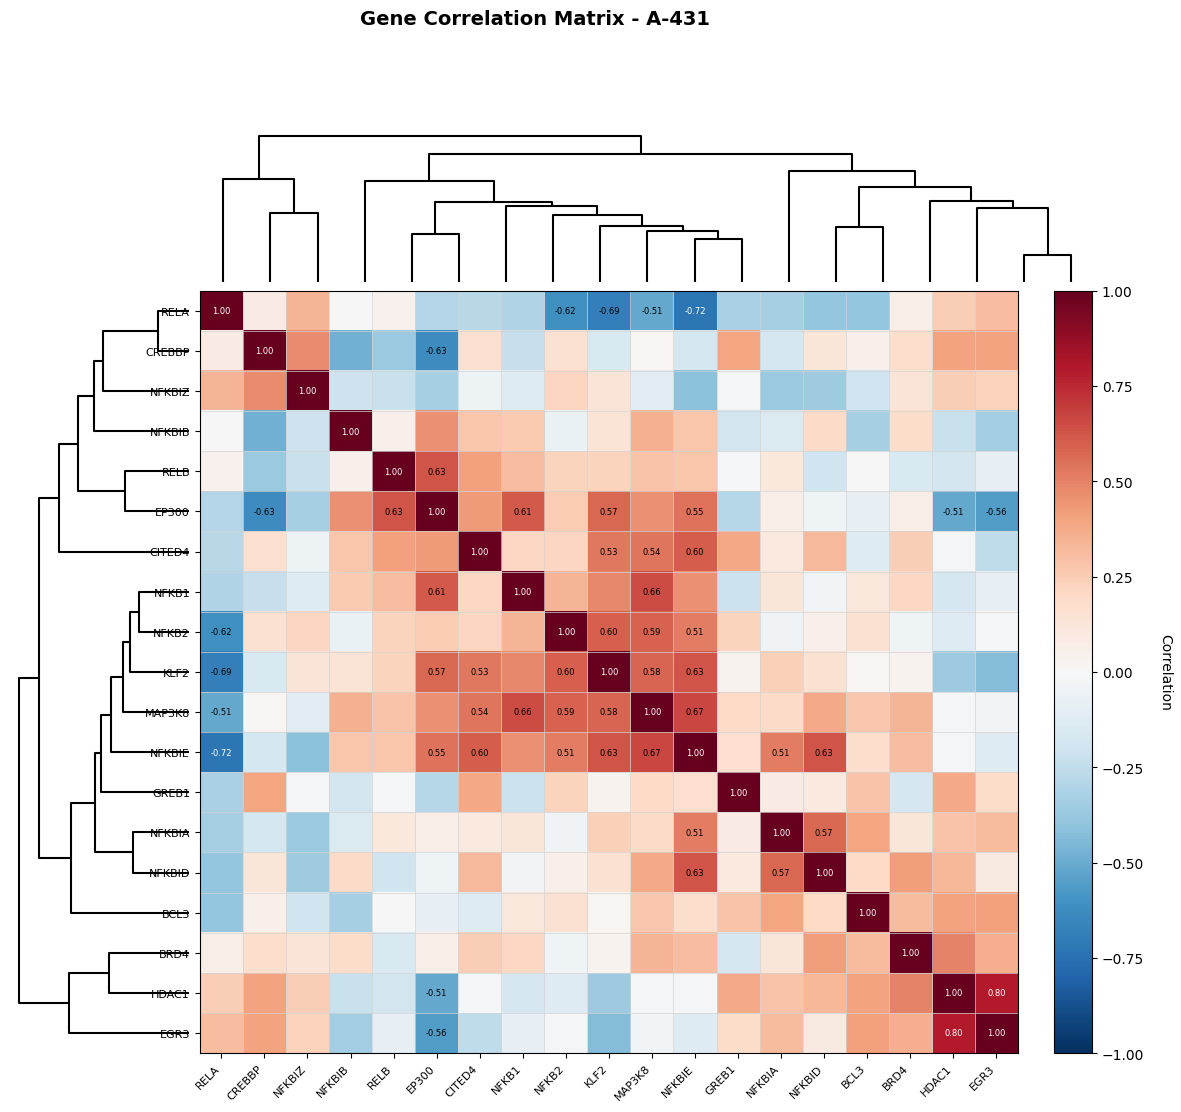

In [26]:
# Create figure with dendrogram and heatmap
fig = plt.figure(figsize=(14, 12))
gs = fig.add_gridspec(2, 2, width_ratios=[0.2, 1], height_ratios=[0.2, 1],
                      hspace=0.02, wspace=0.02)

# Top dendrogram
ax_top = fig.add_subplot(gs[0, 1])
dendrogram(linkage_matrix, ax=ax_top, orientation='top', no_labels=True,
           color_threshold=0, above_threshold_color='k')
ax_top.axis('off')

# Left dendrogram
ax_left = fig.add_subplot(gs[1, 0])
dendrogram(linkage_matrix, ax=ax_left, orientation='left', no_labels=True,
           color_threshold=0, above_threshold_color='k')
ax_left.axis('off')

# Heatmap
ax = fig.add_subplot(gs[1, 1])
im = ax.imshow(reordered_corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')

# Colorbar
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Correlation', rotation=270, labelpad=20)

# Grid
ax.set_xticks(np.arange(len(reordered_genes)) - 0.5, minor=True)
ax.set_yticks(np.arange(len(reordered_genes)) - 0.5, minor=True)
ax.grid(which="minor", color="lightgray", linestyle='-', linewidth=0.5)
ax.tick_params(which="minor", size=0)

# Labels
ax.set_xticks(range(len(reordered_genes)))
ax.set_yticks(range(len(reordered_genes)))
ax.set_xticklabels(reordered_genes, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(reordered_genes, fontsize=8)

# Add correlation values for strong correlations
for i in range(len(reordered_genes)):
    for j in range(len(reordered_genes)):
        if abs(reordered_corr[i, j]) > 0.5:
            color = 'white' if abs(reordered_corr[i, j]) > 0.7 else 'black'
            ax.text(j, i, f'{reordered_corr[i, j]:.2f}',
                   ha="center", va="center", color=color, fontsize=6)

plt.suptitle(f'Gene Correlation Matrix - {CELL_LINE}', fontsize=14, fontweight='bold')
plt.savefig(f'{RESULT_DIR}/{CELL_LINE}_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

## Visualize: Network Graph

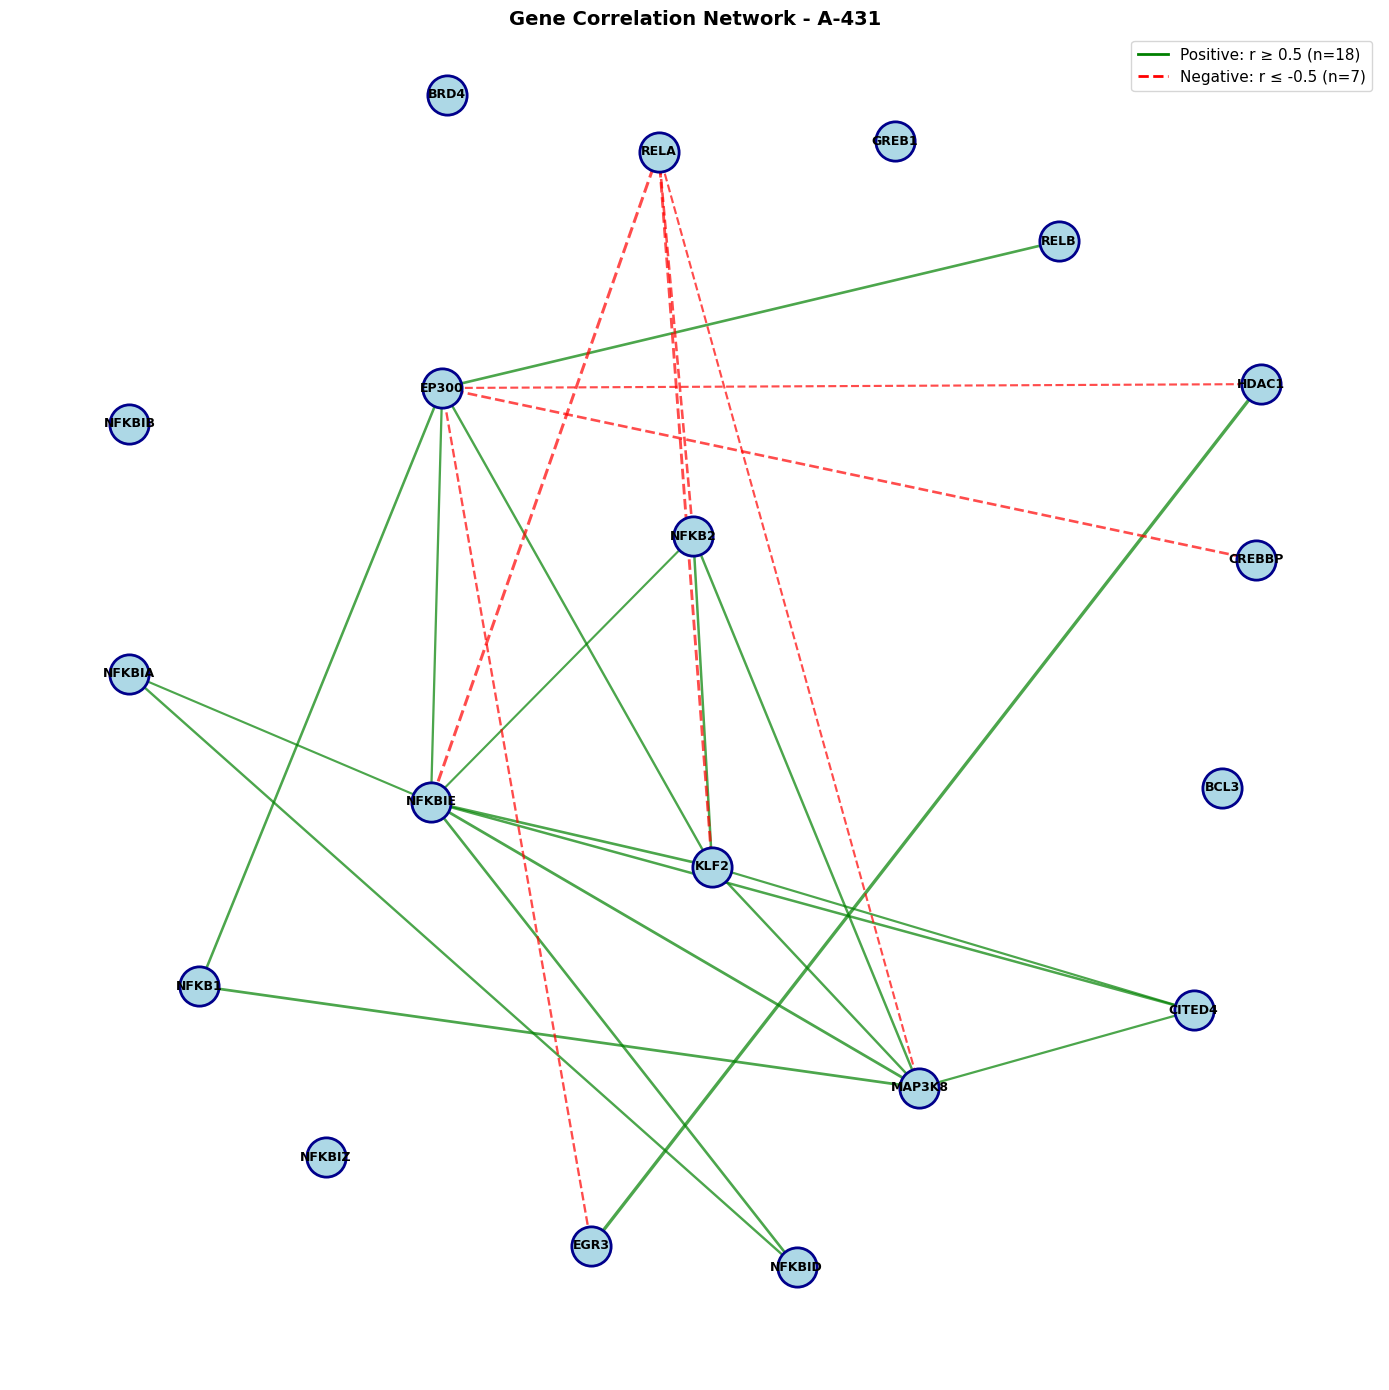


Network: 19 nodes, 25 edges
Positive edges: 18
Negative edges: 7


In [27]:
# Build network graph
G = nx.Graph()
G.add_nodes_from(reordered_genes)

# Add edges based on correlation thresholds
positive_edges = []
negative_edges = []
pos_weights = []
neg_weights = []

for i in range(len(reordered_genes)):
    for j in range(i+1, len(reordered_genes)):
        corr = reordered_corr[i, j]
        
        if corr >= POS_THRESHOLD:
            edge = (reordered_genes[i], reordered_genes[j])
            G.add_edge(*edge, weight=corr, edge_type='positive')
            positive_edges.append(edge)
            pos_weights.append(corr)
        elif corr <= -NEG_THRESHOLD:
            edge = (reordered_genes[i], reordered_genes[j])
            G.add_edge(*edge, weight=abs(corr), edge_type='negative')
            negative_edges.append(edge)
            neg_weights.append(abs(corr))

# Visualize network
fig, ax = plt.subplots(figsize=(14, 14))

pos = nx.spring_layout(G, k=2, iterations=50, seed=42)

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=800,
                      edgecolors='darkblue', linewidths=2, ax=ax)

# Draw positive edges (solid, green)
if positive_edges:
    nx.draw_networkx_edges(G, pos, edgelist=positive_edges,
                          edge_color='green', width=[w*3 for w in pos_weights],
                          alpha=0.7, style='solid', ax=ax)

# Draw negative edges (dashed, red)
if negative_edges:
    nx.draw_networkx_edges(G, pos, edgelist=negative_edges,
                          edge_color='red', width=[w*3 for w in neg_weights],
                          alpha=0.7, style='dashed', ax=ax)

# Labels
nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold', ax=ax)

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='green', linewidth=2, linestyle='solid',
           label=f'Positive: r ≥ {POS_THRESHOLD} (n={len(positive_edges)})'),
    Line2D([0], [0], color='red', linewidth=2, linestyle='dashed',
           label=f'Negative: r ≤ -{NEG_THRESHOLD} (n={len(negative_edges)})')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=11)

ax.set_title(f'Gene Correlation Network - {CELL_LINE}', fontsize=14, fontweight='bold')
ax.axis('off')

plt.tight_layout()
plt.savefig(f'{RESULT_DIR}/{CELL_LINE}_correlation_network.png', dpi=300, bbox_inches='tight')
plt.show()

# Save network
nx.write_gml(G, f'{RESULT_DIR}/{CELL_LINE}_correlation_network.gml')

print(f"\nNetwork: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"Positive edges: {len(positive_edges)}")
print(f"Negative edges: {len(negative_edges)}")

## Summary

**Outputs:**
- `{CELL_LINE}_expression.csv` - Raw mean expression per gene per cell
- `{CELL_LINE}_expression_zscore.csv` - Z-score normalized expression
- `{CELL_LINE}_correlation_clustered.csv` - Clustered correlation matrix
- `{CELL_LINE}_correlation_heatmap.png` - Heatmap with dendrogram
- `{CELL_LINE}_correlation_network.png` - Network graph visualization
- `{CELL_LINE}_correlation_network.gml` - Network file for Cytoscape

**Interpretation:**
- **Clusters** indicate genes with similar expression patterns across cells
- **Network hubs** are genes with many correlations (potential regulators)
- **Positive edges** suggest co-expression or functional similarity
- **Negative edges** suggest antagonistic or compensatory relationships